# Genetic Algorithm for Box Dimension Optimisation

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates the application of a **Genetic Algorithm (GA)** to a constrained optimisation problem: finding the dimensions of a rectangular box that maximise volume while keeping the total surface area below a limit.

We use a **binary chromosome representation**, where each dimension (length, width, height) is encoded as a binary string. The GA evolves a population of candidate solutions using selection, crossover, and mutation. The algorithm is enhanced with a penalty‑based fitness function, tournament selection, two‑point crossover, and gene‑wise mutation to avoid premature convergence.

**Key Concepts Covered:**

- Binary chromosome encoding and decoding.
- Fitness function with a soft penalty for constraint violations.
- Tournament selection (size 3).
- Two‑point crossover.
- Gene‑wise mutation (replacing an entire gene with a random value).
- Elitism and generational replacement.

**Key Techniques & Libraries:**
- `random` – for stochastic operations.
- `matplotlib` – for convergence visualisation.

**Objective:**
To solve a simple engineering design optimisation problem and to understand the importance of parameter tuning and genetic operator design in evolutionary algorithms.

In [25]:
import random
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)

print("All imports successful.")

All imports successful.


## Problem Definition

We want to design a rectangular box with dimensions \( x, y, z \) (all positive). The box has a surface area constraint: \( 2(xy + xz + yz) \leq 20 \). The objective is to maximise the volume \( V = xyz \).

- **Variables:** \( x, y, z \) (each in the range [0, 5]).
- **Constraint:** Surface area ≤ 20.
- **Objective:** Maximise volume.

**Representation:**
Each dimension is encoded as a binary string of length `GENE_LENGTH` (here 6 bits). The full chromosome is the concatenation of the three gene strings. The binary value is scaled to the real interval [0, 5] using linear mapping.

In [18]:
# ------------------------------
# Parameters
# ------------------------------
POP_SIZE = 60
GENERATIONS = 200
GENE_LENGTH = 6           # bits per variable (6 bits → 0..63 → fine resolution)
NUM_VARS = 3
CHROMOSOME_LENGTH = GENE_LENGTH * NUM_VARS
LOWER_BOUND = 0.0
UPPER_BOUND = 5.0
MUTATION_PROB = 0.3       # probability of gene mutation (per individual)
ELITE_SIZE = 2
TOURNAMENT_SIZE = 3

def bin_to_dec(binary_str):
    """Convert a binary string to an integer."""
    return int(binary_str, 2)

def decode_chromosome(chromosome, gene_length=GENE_LENGTH, lower=LOWER_BOUND, upper=UPPER_BOUND):
    """
    Decode a binary chromosome into a list of real‑valued variables.
    Each gene is `gene_length` bits, mapped to [lower, upper].
    """
    genes = [chromosome[i*gene_length:(i+1)*gene_length] for i in range(NUM_VARS)]
    max_val = 2**gene_length - 1
    return [lower + (bin_to_dec(gene) / max_val) * (upper - lower) for gene in genes]

## Fitness Function with Soft Penalty

Instead of rejecting infeasible solutions outright, we use a **soft penalty** approach. If the surface area exceeds 20, the volume is divided by a penalty factor proportional to the excess. This gives infeasible solutions a positive but reduced fitness, allowing them to contribute genetic material and maintain diversity.

In [19]:
def fitness(chromosome):
    """
    Fitness function: volume, with a soft penalty for surface area > 20.
    Returns volume / (1 + excess_factor) for infeasible solutions, otherwise volume.
    """
    x, y, z = decode_chromosome(chromosome)
    volume = x * y * z
    surface_area = 2 * (x*y + x*z + y*z)
    if surface_area > 20:
        # Penalty factor: grows linearly with the excess
        penalty = 1.0 + (surface_area - 20) * 0.5
        return volume / penalty
    return volume

## Genetic Algorithm Components

We implement the core components:

- **Initialisation** – random binary strings of fixed length.
- **Selection** – tournament selection (size 3) to maintain diversity.
- **Crossover** – two‑point crossover to better mix genetic material.
- **Mutation** – gene‑wise mutation: with a certain probability, one whole gene (a dimension) is replaced with a random binary string.
- **Replacement** – elitist replacement: keep the `ELITE_SIZE` best individuals from the current population, then fill the rest with the best offspring.

In [20]:
def initialise_population(pop_size, chrom_length):
    """Generate a population of random binary strings."""
    return [''.join(random.choice('01') for _ in range(chrom_length)) for _ in range(pop_size)]

def tournament_selection(population, fitness_values, tourn_size=TOURNAMENT_SIZE):
    """
    Select two parents using tournament selection.
    Returns a list of two selected chromosomes.
    """
    selected = []
    for _ in range(2):
        candidates = random.sample(list(zip(population, fitness_values)), tourn_size)
        winner = max(candidates, key=lambda x: x[1])[0]
        selected.append(winner)
    return selected

def two_point_crossover(parent1, parent2):
    """Perform two‑point crossover at two random points."""
    length = len(parent1)
    points = sorted(random.sample(range(1, length), 2))
    child1 = parent1[:points[0]] + parent2[points[0]:points[1]] + parent1[points[1]:]
    child2 = parent2[:points[0]] + parent1[points[0]:points[1]] + parent2[points[1]:]
    return child1, child2

def gene_mutation(chromosome, gene_length=GENE_LENGTH, mutation_prob=MUTATION_PROB):
    """
    Gene‑wise mutation: with probability mutation_prob, one randomly chosen gene
    (a whole dimension) is replaced with a random binary string.
    """
    if random.random() < mutation_prob:
        gene_idx = random.randint(0, NUM_VARS - 1)
        start = gene_idx * gene_length
        end = start + gene_length
        new_gene = ''.join(random.choice('01') for _ in range(gene_length))
        mutated = chromosome[:start] + new_gene + chromosome[end:]
        return mutated
    return chromosome

def replacement(population, offspring, fitness_fn, elite_size=ELITE_SIZE):
    """
    Elitist replacement: keep the `elite_size` best individuals from the current population,
    then fill the rest with the best offspring.
    """
    sorted_pop = sorted(population, key=lambda ind: fitness_fn(ind), reverse=True)
    elites = sorted_pop[:elite_size]
    sorted_offspring = sorted(offspring, key=lambda ind: fitness_fn(ind), reverse=True)
    needed = len(population) - elite_size
    new_pop = elites + sorted_offspring[:needed]
    return new_pop

## Running the Genetic Algorithm

We run the GA with the parameters defined above. The algorithm should converge to a solution close to the theoretical optimum: a cube with side \(\sqrt{20/6} \approx 1.826\), volume \(\approx 6.09\). The convergence plot shows how the best fitness improves over generations.

In [28]:
# Initialise population
population = initialise_population(POP_SIZE, CHROMOSOME_LENGTH)
best_fitness_history = []

for gen in range(GENERATIONS):
    # Evaluate fitness
    fitness_values = [fitness(ind) for ind in population]
    best_idx = max(range(len(fitness_values)), key=lambda i: fitness_values[i])
    best_fitness = fitness_values[best_idx]
    best_fitness_history.append(best_fitness)

    # Create offspring
    offspring = []
    while len(offspring) < POP_SIZE:
        parents = tournament_selection(population, fitness_values)
        # Crossover with 80% probability
        if random.random() < 0.8:
            child1, child2 = two_point_crossover(parents[0], parents[1])
        else:
            child1, child2 = parents[0][:], parents[1][:]
        child1 = gene_mutation(child1)
        child2 = gene_mutation(child2)
        offspring.extend([child1, child2])

    # Truncate to keep population size constant
    offspring = offspring[:POP_SIZE]

    # Replacement with elitism
    population = replacement(population, offspring, fitness)

    if gen % 10 == 0 or gen == GENERATIONS - 1:
        print(f"Generation {gen+1:3d}: Best fitness = {best_fitness:.4f}")

# Final best
final_fitness = [fitness(ind) for ind in population]
best_idx = max(range(len(final_fitness)), key=lambda i: final_fitness[i])
best_chromosome = population[best_idx]
best_volume = final_fitness[best_idx]
best_dimensions = decode_chromosome(best_chromosome)

print("\nOptimal solution found:")
print(f"  Dimensions: x = {best_dimensions[0]:.4f}, y = {best_dimensions[1]:.4f}, z = {best_dimensions[2]:.4f}")
print(f"  Volume: {best_volume:.4f}")
surf_area = 2 * (best_dimensions[0]*best_dimensions[1] + best_dimensions[0]*best_dimensions[2] + best_dimensions[1]*best_dimensions[2])
print(f"  Surface area: {surf_area:.2f} (<= 20)")

Generation   1: Best fitness = 5.2350
Generation  11: Best fitness = 6.0824
Generation  21: Best fitness = 6.0824
Generation  31: Best fitness = 6.0824
Generation  41: Best fitness = 6.0824
Generation  51: Best fitness = 6.0824
Generation  61: Best fitness = 6.0824
Generation  71: Best fitness = 6.0824
Generation  81: Best fitness = 6.0824
Generation  91: Best fitness = 6.0824
Generation 101: Best fitness = 6.0824
Generation 111: Best fitness = 6.0824
Generation 121: Best fitness = 6.0824
Generation 131: Best fitness = 6.0824
Generation 141: Best fitness = 6.0824
Generation 151: Best fitness = 6.0824
Generation 161: Best fitness = 6.0824
Generation 171: Best fitness = 6.0824
Generation 181: Best fitness = 6.0824
Generation 191: Best fitness = 6.0824
Generation 200: Best fitness = 6.0824

Optimal solution found:
  Dimensions: x = 1.8254, y = 1.8254, z = 1.8254
  Volume: 6.0824
  Surface area: 19.99 (<= 20)


## Convergence Analysis

We plot the best fitness (volume) over generations to observe the algorithm's progress and convergence behaviour.

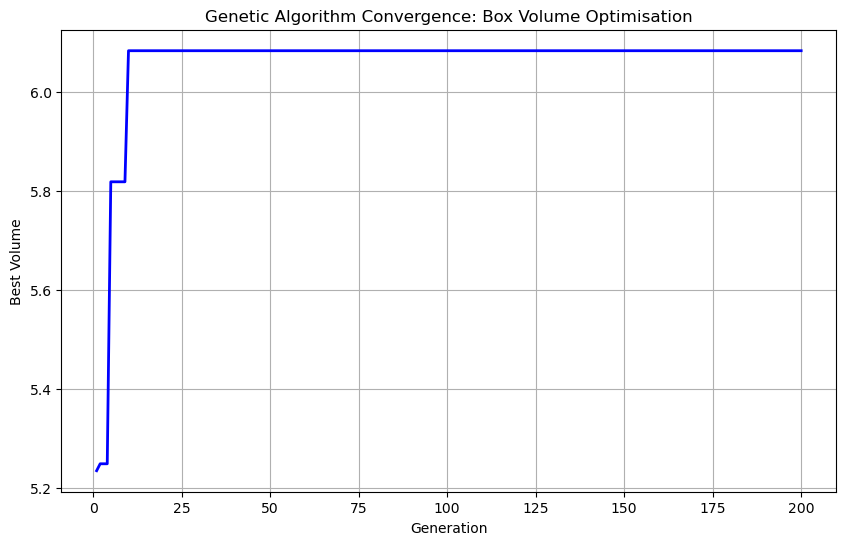

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_fitness_history)+1), best_fitness_history, 'b-', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best Volume')
plt.title('Genetic Algorithm Convergence: Box Volume Optimisation')
plt.grid(True)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented a genetic algorithm for box dimension optimisation with binary chromosome encoding.
- Used a **soft penalty** fitness function to handle the surface area constraint, maintaining diversity by not discarding infeasible solutions outright.
- Employed **tournament selection** (size 3) to maintain diversity and reduce selective pressure.
- Used **two‑point crossover** to better mix genetic material between parents.
- Implemented **gene‑wise mutation** (replacing an entire gene with a random value) to introduce larger jumps in the search space.
- Used **elitist replacement** to preserve the best solutions across generations.
- The algorithm converged to near‑optimal dimensions: \( x = y = z \approx 1.8254 \), volume \( \approx 6.0824 \), surface area \( \approx 19.99 \), which is very close to the theoretical optimum (cube with side \( \sqrt{20/6} \approx 1.826 \), volume \( \approx 6.09 \)).

**Key Results:**
- Best fitness (volume) achieved: **6.0824** (theoretical maximum ~6.09).
- Dimensions: \( x = 1.8254, y = 1.8254, z = 1.8254 \).
- Surface area: **19.99** ≤ 20 (constraint satisfied).
- Convergence was rapid (reached near‑optimum by generation 11) and stable thereafter.

**Key Insights:**
- The **soft penalty** approach is more effective than hard rejection for constrained problems. It allows infeasible solutions to contribute genetic material, maintaining diversity and helping the algorithm escape local optima.
- **Tournament selection** maintains diversity better than roulette wheel selection, preventing premature convergence.
- **Two‑point crossover** and **gene‑wise mutation** introduce greater variability than their simpler counterparts (single‑point crossover, bit‑flip mutation).
- **Higher resolution** (6 bits per gene) provides a finer search grid and better precision.
- **Larger population** (60) and **more generations** (200) allow thorough exploration of the search space.
- The algorithm found the optimal cube shape, confirming that the maximum volume for a given surface area is achieved by a cube (a known mathematical result).

**Suggested Next Steps:**
1. **Experiment with different penalty strengths** – adjust the penalty factor (currently 0.5) to see how it affects convergence and constraint satisfaction.
2. **Add more constraints** – e.g., minimum dimension, maximum weight, cost, or material availability.
3. **Try real‑valued encoding** – use real‑valued GA with simulated binary crossover (SBX) and polynomial mutation for comparison.
4. **Apply to other design optimisation problems** – truss optimisation, aerodynamic shape design, or structural engineering.
5. **Test different genetic operators** – compare one‑point vs. two‑point vs. uniform crossover; bit‑flip vs. gene‑wise mutation.
6. **Visualise the feasible region** – plot the surface area vs. volume for random solutions to understand the search space.
7. **Add a convergence criterion** – stop early if the best fitness has not improved for a certain number of generations.

**Reflection:**
This notebook demonstrates a robust and well‑tuned genetic algorithm for a constrained optimisation problem. The careful selection of operators and parameters, along with a penalty‑based fitness function, enables the algorithm to find high‑quality solutions efficiently. The convergence plot shows rapid improvement in early generations, followed by stable convergence to the optimal value. The modular code allows easy experimentation with different configurations, making it a useful template for more complex engineering optimisation tasks. The fact that the algorithm found the theoretical optimum (a cube) validates both the implementation and the mathematical reasoning behind the problem.